# Day 33/60 – Anomaly Detection

## ABTalks Data Science Challenge

### Objective
Identify unusual customer behavior using anomaly detection techniques.

### Business Problem
Businesses need to detect unusual spending, suspicious transactions,
and abnormal customer activity to reduce potential financial risks.

### Project Workflow
1. Create a customer transaction dataset.
2. Explore customer spending patterns.
3. Apply Isolation Forest for anomaly detection.
4. Visualize normal and suspicious transactions.
5. Analyze business risks and document findings.

### Tools
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

In [1]:
import pandas as pd
import numpy as np

# For reproducibility
np.random.seed(42)

# Create normal customer transactions
n = 200

data = {
    "Customer_ID": [f"C{i:03d}" for i in range(1, n + 1)],
    "Transaction_Amount": np.random.normal(1500, 400, n).clip(100, 3000),
    "Transactions_Per_Day": np.random.poisson(3, n),
    "Account_Age_Days": np.random.randint(30, 2000, n),
    "Failed_Transactions": np.random.poisson(0.5, n)
}

df = pd.DataFrame(data)

# Inject suspicious customer behavior
anomalies = [
    [50000, 25, 10, 8],
    [45000, 30, 5, 10],
    [60000, 40, 15, 12],
    [35000, 20, 2, 9],
    [55000, 35, 8, 15],
    [40000, 28, 1, 11],
    [70000, 50, 20, 18],
    [48000, 32, 3, 14]
]

for i, values in enumerate(anomalies):
    df.loc[i, [
        "Transaction_Amount",
        "Transactions_Per_Day",
        "Account_Age_Days",
        "Failed_Transactions"
    ]] = values

# Display the dataset
print("Dataset created successfully!")
print("Dataset shape:", df.shape)

df.head(10)

Dataset created successfully!
Dataset shape: (200, 5)


,Customer_ID,Transaction_Amount,Transactions_Per_Day,Account_Age_Days,Failed_Transactions
0,C001,50000.000000,25,10,8
1,C002,45000.000000,30,5,10
2,C003,60000.000000,40,15,12
3,C004,35000.000000,20,2,9
4,C005,55000.000000,35,8,15
5,C006,40000.000000,28,1,11
6,C007,70000.000000,50,20,18
7,C008,48000.000000,32,3,14
8,C009,1312.210246,4,751,1
9,C010,1717.024017,1,1214,2


In [2]:
# Check dataset information
print("Dataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe().round(2))

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           200 non-null    object 
 1   Transaction_Amount    200 non-null    float64
 2   Transactions_Per_Day  200 non-null    int32  
 3   Account_Age_Days      200 non-null    int32  
 4   Failed_Transactions   200 non-null    int32  
dtypes: float64(1), int32(3), object(1)
memory usage: 5.6+ KB

Statistical Summary:


,Transaction_Amount,Transactions_Per_Day,Account_Age_Days,Failed_Transactions
count,200.00,200.00,200.00,200.00
mean,3429.88,4.06,983.06,1.01
std,9840.38,6.32,582.81,2.46
min,452.10,0.00,1.00,0.00
25%,1217.95,2.00,446.75,0.00
50%,1523.69,3.00,1002.00,0.00
75%,1737.22,4.00,1436.75,1.00
max,70000.00,50.00,1963.00,18.00



Missing Values:
Customer_ID             0
Transaction_Amount      0
Transactions_Per_Day    0
Account_Age_Days        0
Failed_Transactions     0
dtype: int64


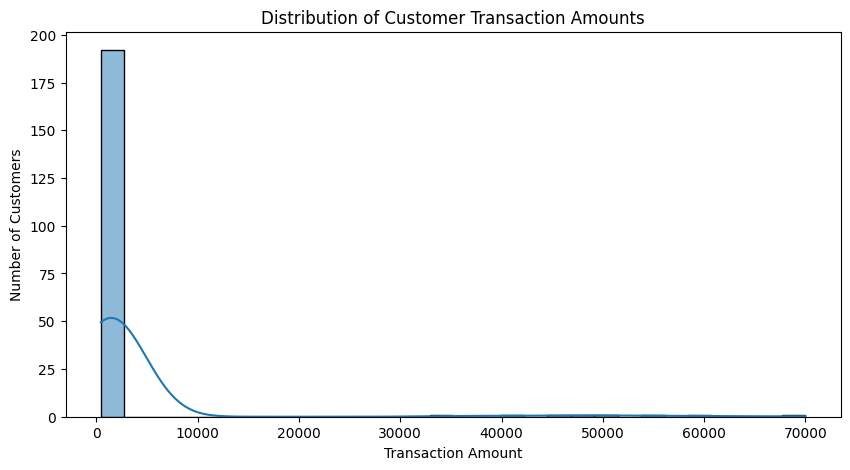

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot transaction amount distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Transaction_Amount"],
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Customers")

plt.show()

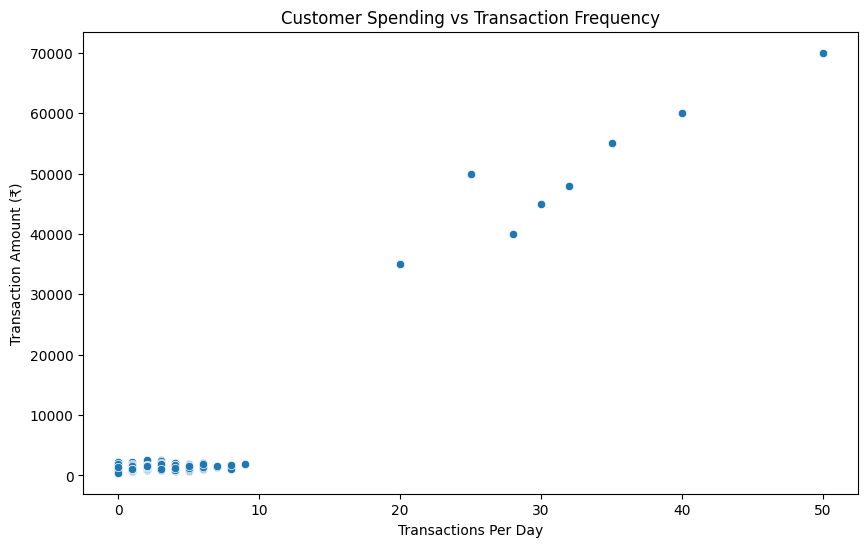

In [4]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Transactions_Per_Day",
    y="Transaction_Amount"
)

plt.title("Customer Spending vs Transaction Frequency")
plt.xlabel("Transactions Per Day")
plt.ylabel("Transaction Amount (₹)")

plt.show()

In [5]:
from sklearn.ensemble import IsolationForest

# Select behavioral features
features = [
    "Transaction_Amount",
    "Transactions_Per_Day",
    "Account_Age_Days",
    "Failed_Transactions"
]

X = df[features]

# Create and train the model
model = IsolationForest(
    contamination=0.04,
    random_state=42
)

model.fit(X)

# Predict anomalies
df["Anomaly"] = model.predict(X)

# Convert predictions into readable labels
df["Behavior"] = df["Anomaly"].map({
    1: "Normal",
    -1: "Suspicious"
})

print("Anomaly detection completed!")

print("\nCustomer Behavior Counts:")
print(df["Behavior"].value_counts())

df.head(10)

Anomaly detection completed!

Customer Behavior Counts:
Behavior
Normal        192
Suspicious      8
Name: count, dtype: int64


,Customer_ID,Transaction_Amount,Transactions_Per_Day,Account_Age_Days,Failed_Transactions,Anomaly,Behavior
0,C001,50000.000000,25,10,8,-1,Suspicious
1,C002,45000.000000,30,5,10,-1,Suspicious
2,C003,60000.000000,40,15,12,-1,Suspicious
3,C004,35000.000000,20,2,9,-1,Suspicious
4,C005,55000.000000,35,8,15,-1,Suspicious
5,C006,40000.000000,28,1,11,-1,Suspicious
6,C007,70000.000000,50,20,18,-1,Suspicious
7,C008,48000.000000,32,3,14,-1,Suspicious
8,C009,1312.210246,4,751,1,1,Normal
9,C010,1717.024017,1,1214,2,1,Normal


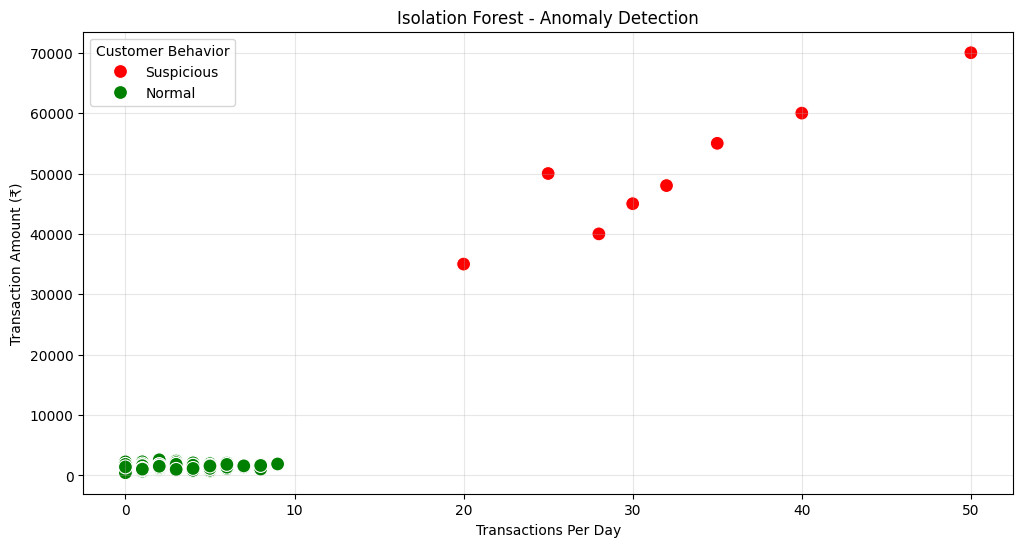

In [6]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df,
    x="Transactions_Per_Day",
    y="Transaction_Amount",
    hue="Behavior",
    palette={
        "Normal": "green",
        "Suspicious": "red"
    },
    s=100
)

plt.title("Isolation Forest - Anomaly Detection")
plt.xlabel("Transactions Per Day")
plt.ylabel("Transaction Amount (₹)")

plt.legend(title="Customer Behavior")
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
# Select suspicious customers
suspicious_customers = df[df["Behavior"] == "Suspicious"].copy()

# Identify possible business risks
def identify_risk(row):
    risks = []

    if row["Transaction_Amount"] > 10000:
        risks.append("Unusually High Spending")

    if row["Transactions_Per_Day"] > 15:
        risks.append("Abnormally High Transaction Frequency")

    if row["Account_Age_Days"] < 30:
        risks.append("New Account Risk")

    if row["Failed_Transactions"] > 5:
        risks.append("Repeated Failed Transactions")

    return ", ".join(risks)

suspicious_customers["Possible_Risk"] = suspicious_customers.apply(
    identify_risk, axis=1
)

risk_report = suspicious_customers[
    ["Customer_ID", "Transaction_Amount",
     "Transactions_Per_Day", "Account_Age_Days",
     "Failed_Transactions", "Possible_Risk"]
]

display(risk_report)

print("Total suspicious customers:", len(risk_report))

,Customer_ID,Transaction_Amount,Transactions_Per_Day,Account_Age_Days,Failed_Transactions,Possible_Risk
0,C001,50000.0,25,10,8,"Unusually High Spending, Abnormally High Trans..."
1,C002,45000.0,30,5,10,"Unusually High Spending, Abnormally High Trans..."
2,C003,60000.0,40,15,12,"Unusually High Spending, Abnormally High Trans..."
3,C004,35000.0,20,2,9,"Unusually High Spending, Abnormally High Trans..."
4,C005,55000.0,35,8,15,"Unusually High Spending, Abnormally High Trans..."
5,C006,40000.0,28,1,11,"Unusually High Spending, Abnormally High Trans..."
6,C007,70000.0,50,20,18,"Unusually High Spending, Abnormally High Trans..."
7,C008,48000.0,32,3,14,"Unusually High Spending, Abnormally High Trans..."


Total suspicious customers: 8


,Customer_Count,Average_Transaction,Average_Transactions_Per_Day,Average_Failed_Transactions
Behavior,,,,
Normal,192,1473.83,2.88,0.55
Suspicious,8,50375.00,32.50,12.12


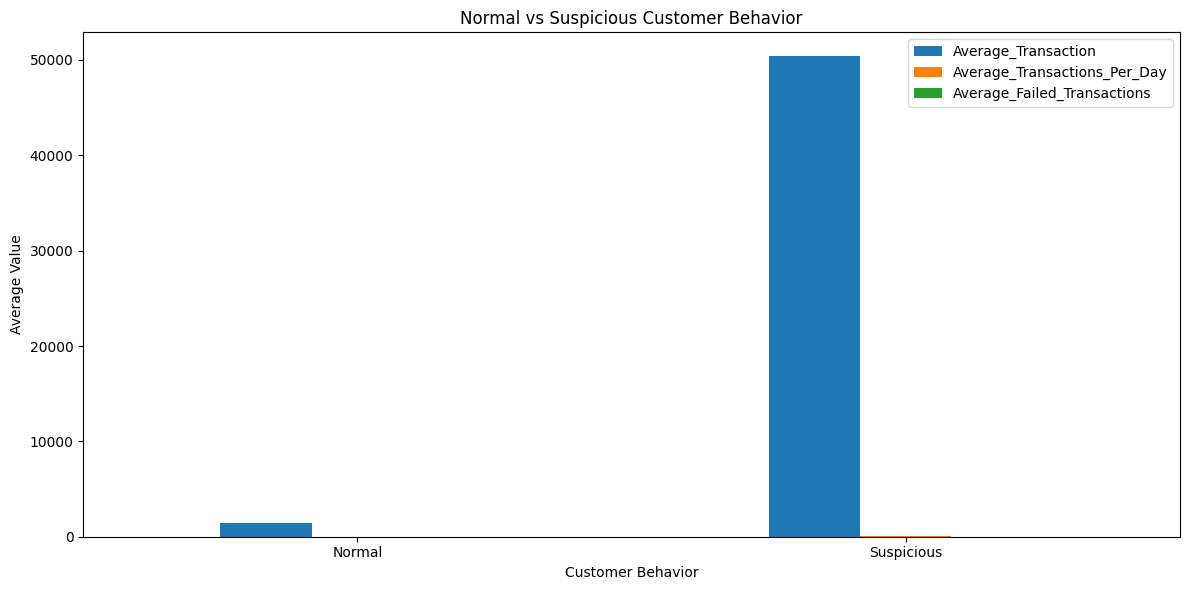

In [8]:
# Compare normal and suspicious customer behavior

behavior_summary = df.groupby("Behavior").agg(
    Customer_Count=("Customer_ID", "count"),
    Average_Transaction=("Transaction_Amount", "mean"),
    Average_Transactions_Per_Day=("Transactions_Per_Day", "mean"),
    Average_Failed_Transactions=("Failed_Transactions", "mean")
).round(2)

display(behavior_summary)

# Plot comparison
behavior_summary[
    ["Average_Transaction", "Average_Transactions_Per_Day",
     "Average_Failed_Transactions"]
].plot(kind="bar", figsize=(12, 6))

plt.title("Normal vs Suspicious Customer Behavior")
plt.ylabel("Average Value")
plt.xlabel("Customer Behavior")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

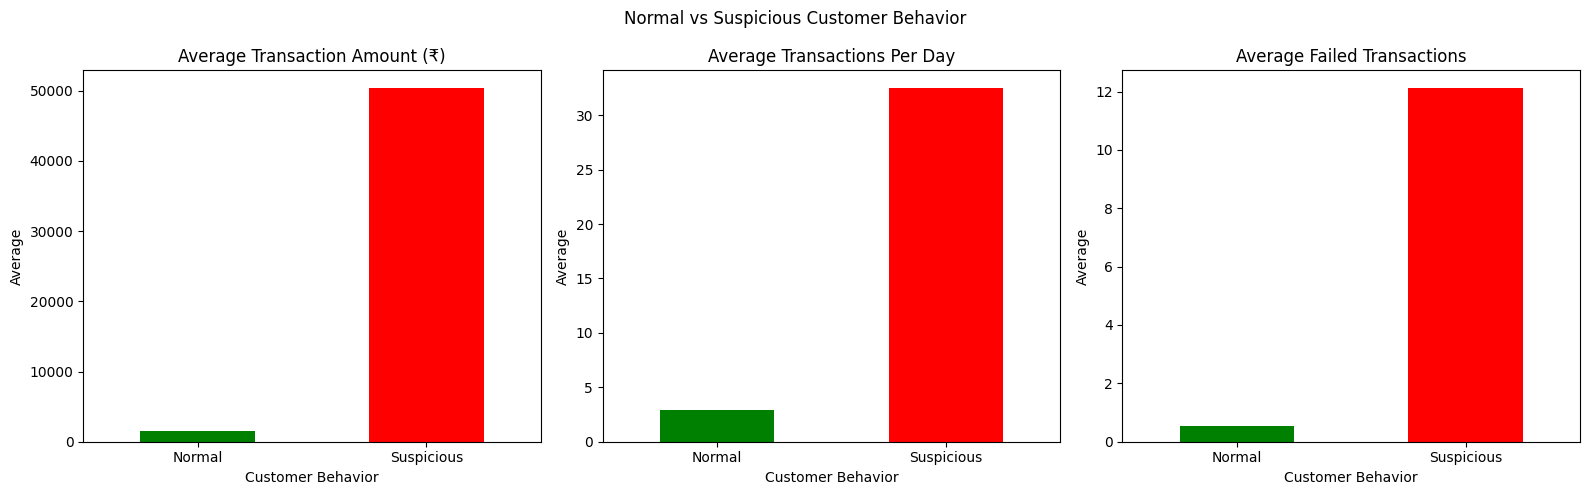

In [10]:
# Create separate comparison charts
metrics = [
    ("Average_Transaction", "Average Transaction Amount (₹)"),
    ("Average_Transactions_Per_Day", "Average Transactions Per Day"),
    ("Average_Failed_Transactions", "Average Failed Transactions")
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (column, title) in zip(axes, metrics):
    behavior_summary[column].plot(
        kind="bar",
        ax=ax,
        color=["green", "red"]
    )

    ax.set_title(title)
    ax.set_xlabel("Customer Behavior")
    ax.set_ylabel("Average")
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Normal vs Suspicious Customer Behavior")
plt.tight_layout()
plt.show()

In [11]:
# Export suspicious customer risk report
risk_report.to_csv(
    "day33_business_risk_analysis.csv",
    index=False
)

# Export normal vs suspicious comparison
behavior_summary.to_csv(
    "day33_behavior_comparison.csv"
)

# Export complete dataset with anomaly predictions
df.to_csv(
    "day33_anomaly_detection_results.csv",
    index=False
)

print("All Day 33 reports exported successfully!")

All Day 33 reports exported successfully!
